# Learning-to-Rank Demo — MedPRS Journal Recommendation

Notebook này so sánh performance **trước** và **sau** khi áp dụng Learning-to-Rank (LambdaMART) lên top-10 candidates từ base model.

**Pipeline:**
1. Load `test_detailed_predictions.csv` (demo data)
2. Split papers thành train / val / test
3. Đánh giá **Baseline** (Base_Score ranking)
4. Train **L2R model** (LightGBM LambdaMART)
5. Đánh giá **After L2R**
6. So sánh và visualize kết quả

> **Kernel cần chọn trong VSCode:** `Python 3.9.21 ('base': conda)` — đường dẫn `C:\Users\Admin\anaconda3\python.exe`

In [1]:
# --- Environment check ---
import sys, subprocess
print('Python:', sys.executable)
print('Version:', sys.version.split('\n')[0])

required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'lightgbm', 'joblib']
missing = []
for pkg in required:
    try:
        mod = __import__(pkg)
        print(f'  OK  {pkg} {getattr(mod, "__version__", "")}') 
    except ImportError:
        print(f'  MISSING  {pkg}')
        missing.append(pkg)

if missing:
    raise RuntimeError(f'Missing packages: {missing}. Run: conda install {" ".join(missing)}')

Python: c:\Users\Admin\anaconda3\python.exe
Version: 3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
  OK  numpy 1.21.6
  OK  pandas 1.4.4
  OK  matplotlib 3.5.2
  OK  seaborn 0.11.2


c:\Users\Admin\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
c:\Users\Admin\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
c:\Users\Admin\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


  OK  lightgbm 4.6.0
  OK  joblib 1.4.2


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Project root = thư mục cha của notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)

Project root: c:\Users\Admin\Downloads\MedPRS


## 1. Load & Explore Data

In [3]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'preprocessed_data', 'test_detailed_predictions.csv')

df_all = pd.read_csv(DATA_PATH)
n_papers = df_all['Paper_ID'].nunique()

print('Shape          :', df_all.shape)
print('Papers         :', f'{n_papers:,}')
print('Rank range     :', df_all['Base_Rank'].min(), '-', df_all['Base_Rank'].max())
print('Correct hits   :', f'{df_all["Is_Correct"].sum():,}', '/', f'{n_papers:,}', 'papers')
print('Columns        :', df_all.columns.tolist())
df_all.head()

Shape          : (2406940, 7)
Papers         : 240,694
Rank range     : 1 - 10
Correct hits   : 225,759 / 240,694 papers
Columns        : ['Paper_ID', 'True_Journal_ID', 'Predicted_Journal_ID', 'Base_Rank', 'Base_Score', 'Aims_Scope_Sim', 'Is_Correct']


,Paper_ID,True_Journal_ID,Predicted_Journal_ID,Base_Rank,Base_Score,Aims_Scope_Sim,Is_Correct
0,0,1292,1292,1,0.500897,0.023608,1
1,0,1292,30,2,0.420862,-0.027843,0
2,0,1292,5,3,0.048466,0.000237,0
3,0,1292,31,4,0.028931,0.012733,0
4,0,1292,3,5,0.000062,0.001938,0


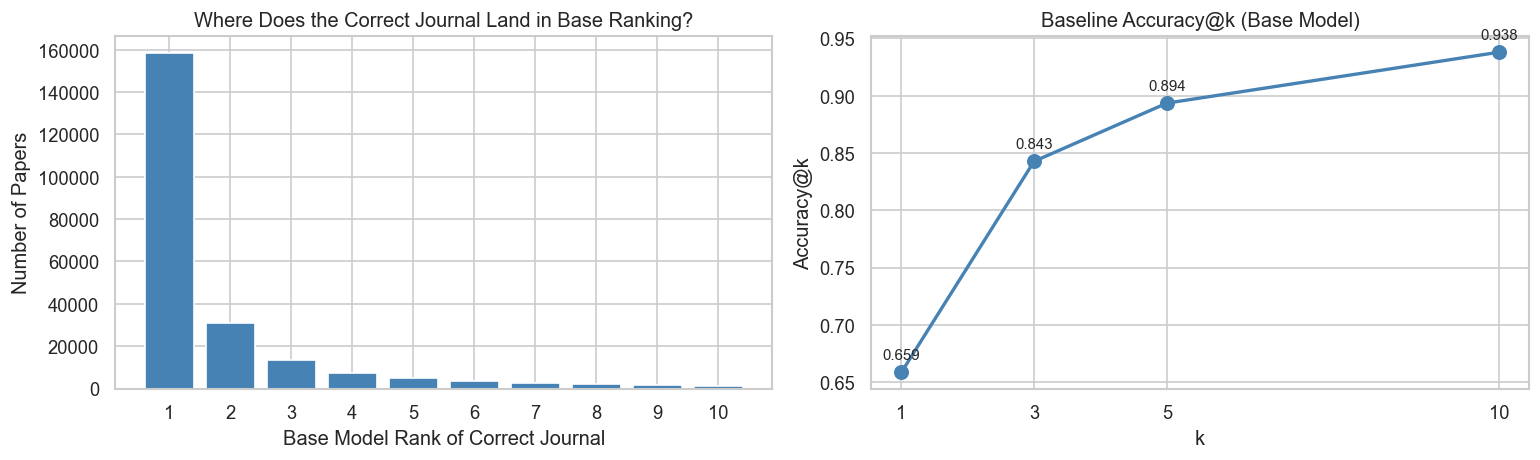

In [4]:
correct_rows = df_all[df_all['Is_Correct'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rank_counts = correct_rows['Base_Rank'].value_counts().sort_index()
axes[0].bar(rank_counts.index, rank_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Base Model Rank of Correct Journal')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('Where Does the Correct Journal Land in Base Ranking?')
axes[0].set_xticks(rank_counts.index)

ks = [1, 3, 5, 10]
acc_baseline = [(correct_rows['Base_Rank'] <= k).sum() / n_papers for k in ks]
axes[1].plot(ks, acc_baseline, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Accuracy@k')
axes[1].set_title('Baseline Accuracy@k (Base Model)')
axes[1].set_xticks(ks)
for k, v in zip(ks, acc_baseline):
    axes[1].annotate('%.3f' % v, (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Train / Val / Test Split

Chia theo Paper_ID (70% train / 15% val / 15% test) để không bị data leakage.

In [5]:
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
RANDOM_SEED = 42

paper_ids = df_all['Paper_ID'].unique().copy()
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(paper_ids)

n = len(paper_ids)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

train_ids = set(paper_ids[:n_train])
val_ids   = set(paper_ids[n_train:n_train + n_val])
test_ids  = set(paper_ids[n_train + n_val:])

df_train = df_all[df_all['Paper_ID'].isin(train_ids)].sort_values(['Paper_ID', 'Base_Rank']).reset_index(drop=True)
df_val   = df_all[df_all['Paper_ID'].isin(val_ids)].sort_values(['Paper_ID', 'Base_Rank']).reset_index(drop=True)
df_test  = df_all[df_all['Paper_ID'].isin(test_ids)].sort_values(['Paper_ID', 'Base_Rank']).reset_index(drop=True)

print('Train : %7s papers  (%s rows)' % (f'{df_train["Paper_ID"].nunique():,}', f'{len(df_train):,}'))
print('Val   : %7s papers  (%s rows)' % (f'{df_val["Paper_ID"].nunique():,}',   f'{len(df_val):,}'))
print('Test  : %7s papers  (%s rows)' % (f'{df_test["Paper_ID"].nunique():,}',  f'{len(df_test):,}'))

Train : 168,485 papers  (1,684,850 rows)
Val   :  36,104 papers  (361,040 rows)
Test  :  36,105 papers  (361,050 rows)


## 3. Helper Functions

In [6]:
FEATURE_COLS = ['base_score', 'base_rank', 'aims_scope_sim', 'domain_sim', 'research_focus_sim']


def build_dataset(df):
    feat = pd.DataFrame({
        'base_score'        : df['Base_Score'].values,
        'base_rank'         : df['Base_Rank'].values,
        'aims_scope_sim'    : df['Aims_Scope_Sim'].values,
        'domain_sim'        : df.get('domain_similarity',        pd.Series(0.0, index=df.index)).values,
        'research_focus_sim': df.get('research_focus_similarity', pd.Series(0.0, index=df.index)).values,
    })
    X      = feat[FEATURE_COLS].values.astype(np.float32)
    y      = df['Is_Correct'].values.astype(np.int32)
    groups = df.groupby('Paper_ID', sort=False).size().values
    return X, y, groups


def dcg_at_k(sorted_relevances, k):
    rel   = sorted_relevances[:k]
    gains = rel / np.log2(np.arange(2, len(rel) + 2))
    return float(gains.sum())


def evaluate(df, score_col, ks=(1, 3, 5, 10)):
    df = df.copy()
    df['L2R_Rank'] = (
        df.groupby('Paper_ID')[score_col]
          .rank(method='first', ascending=False)
          .astype(int)
    )
    mrr      = 0.0
    ndcg     = {k: 0.0 for k in ks}
    acc      = {k: 0   for k in ks}
    n_papers = 0

    for _, grp in df.groupby('Paper_ID'):
        grp_sorted  = grp.sort_values('L2R_Rank')
        relevances  = grp_sorted['Is_Correct'].values
        correct_pos = np.where(relevances == 1)[0]
        if len(correct_pos) > 0:
            mrr += 1.0 / (correct_pos[0] + 1)
        for k in ks:
            ndcg[k] += dcg_at_k(relevances, k)
            if relevances[:k].sum() > 0:
                acc[k] += 1
        n_papers += 1

    metrics = {'MRR': mrr / n_papers}
    for k in ks:
        metrics['NDCG@%d' % k] = ndcg[k] / n_papers
        metrics['Acc@%d'  % k] = acc[k]  / n_papers
    return metrics, df


def print_metrics(name, metrics):
    sep = '-' * 45
    print('\n' + sep)
    print('  ' + name)
    print(sep)
    for k, v in metrics.items():
        print('  %-15s %.4f' % (k, v))


print('Helper functions loaded.')

Helper functions loaded.


## 4. Baseline Evaluation (Before L2R)

In [7]:
KS = [1, 3, 5, 10]

baseline_val_metrics,  _ = evaluate(df_val,  'Base_Score', ks=KS)
baseline_test_metrics, _ = evaluate(df_test, 'Base_Score', ks=KS)

print_metrics('BASELINE  Val',  baseline_val_metrics)
print_metrics('BASELINE  Test', baseline_test_metrics)


---------------------------------------------
  BASELINE  Val
---------------------------------------------
  MRR             0.7620
  NDCG@1          0.6620
  Acc@1           0.6620
  NDCG@3          0.7706
  Acc@3           0.8458
  NDCG@5          0.7913
  Acc@5           0.8958
  NDCG@10         0.8053
  Acc@10          0.9388

---------------------------------------------
  BASELINE  Test
---------------------------------------------
  MRR             0.7583
  NDCG@1          0.6571
  Acc@1           0.6571
  NDCG@3          0.7662
  Acc@3           0.8417
  NDCG@5          0.7878
  Acc@5           0.8938
  NDCG@10         0.8026
  Acc@10          0.9393


## 5. Train L2R Model (LightGBM LambdaMART)

In [8]:
import lightgbm as lgb

X_train, y_train, groups_train = build_dataset(df_train)
X_val,   y_val,   groups_val   = build_dataset(df_val)
X_test,  y_test,  groups_test  = build_dataset(df_test)

print('Train samples : %s  |  Val: %s  |  Test: %s' % (
    f'{len(X_train):,}', f'{len(X_val):,}', f'{len(X_test):,}'))
print('Features      :', FEATURE_COLS)

Train samples : 1,684,850  |  Val: 361,040  |  Test: 361,050
Features      : ['base_score', 'base_rank', 'aims_scope_sim', 'domain_sim', 'research_focus_sim']


In [9]:
params = {
    'objective'        : 'lambdarank',
    'metric'           : 'ndcg',
    'ndcg_eval_at'     : [1, 3, 5, 10],
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_child_samples': 5,
    'random_state'     : 42,
    'verbose'          : -1,
}

train_data = lgb.Dataset(X_train, label=y_train, group=groups_train, feature_name=FEATURE_COLS)
val_data   = lgb.Dataset(X_val,   label=y_val,   group=groups_val,   reference=train_data)

evals_result = {}

model = lgb.train(
    params,
    train_data,
    num_boost_round=300,
    valid_sets=[val_data],
    valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=50),
        lgb.record_evaluation(evals_result),
    ],
)

print('\nBest iteration:', model.best_iteration)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	val's ndcg@1: 0.723161	val's ndcg@3: 0.831779	val's ndcg@5: 0.852428	val's ndcg@10: 0.866479

Best iteration: 2


### Training Curve

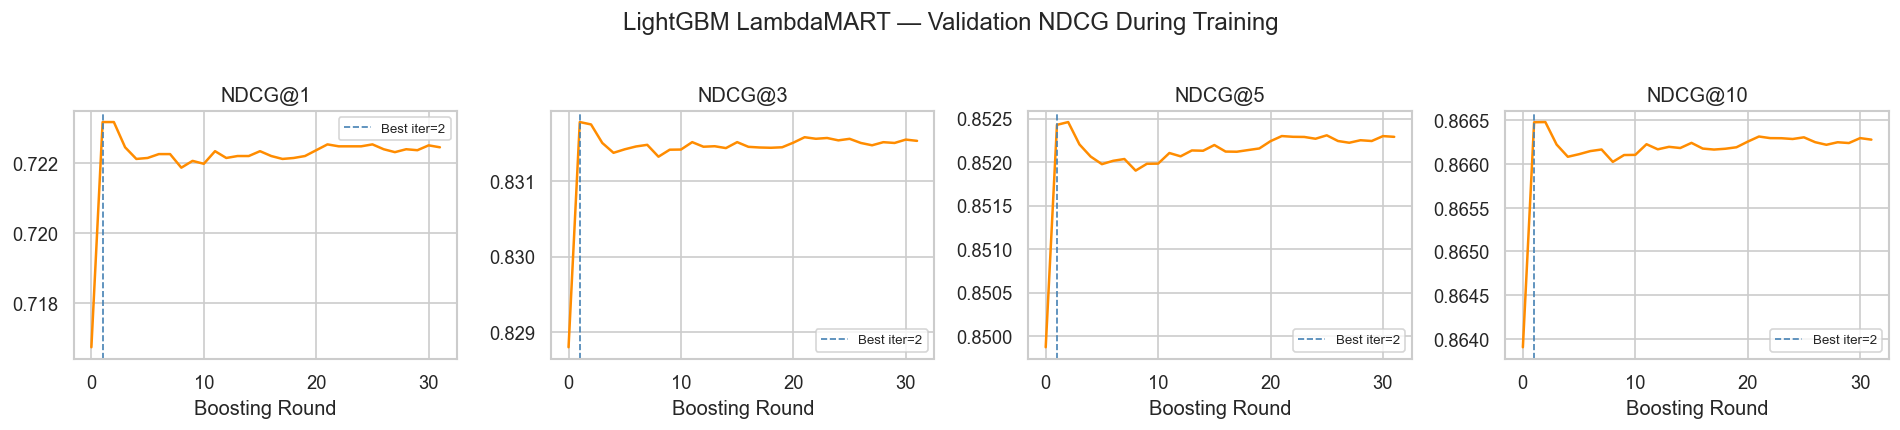

In [10]:
val_metrics = evals_result['val']
n_plots = len(val_metrics)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 3.5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (metric_name, values) in zip(axes, val_metrics.items()):
    ax.plot(values, linewidth=1.5, color='darkorange')
    ax.axvline(model.best_iteration - 1, color='steelblue', linestyle='--',
               linewidth=1, label='Best iter=%d' % model.best_iteration)
    ax.set_title(metric_name.upper())
    ax.set_xlabel('Boosting Round')
    ax.legend(fontsize=8)

plt.suptitle('LightGBM LambdaMART — Validation NDCG During Training', y=1.02)
plt.tight_layout()
plt.show()

## 6. L2R Evaluation (After L2R)

In [11]:
df_val_l2r  = df_val.copy()
df_test_l2r = df_test.copy()

df_val_l2r['L2R_Score']  = model.predict(X_val)
df_test_l2r['L2R_Score'] = model.predict(X_test)

l2r_val_metrics,  df_val_ranked  = evaluate(df_val_l2r,  'L2R_Score', ks=KS)
l2r_test_metrics, df_test_ranked = evaluate(df_test_l2r, 'L2R_Score', ks=KS)

print_metrics('L2R  Val',  l2r_val_metrics)
print_metrics('L2R  Test', l2r_test_metrics)


---------------------------------------------
  L2R  Val
---------------------------------------------
  MRR             0.7618
  NDCG@1          0.6619
  Acc@1           0.6619
  NDCG@3          0.7705
  Acc@3           0.8458
  NDCG@5          0.7912
  Acc@5           0.8957
  NDCG@10         0.8052
  Acc@10          0.9388

---------------------------------------------
  L2R  Test
---------------------------------------------
  MRR             0.7579
  NDCG@1          0.6564
  Acc@1           0.6564
  NDCG@3          0.7659
  Acc@3           0.8416
  NDCG@5          0.7875
  Acc@5           0.8938
  NDCG@10         0.8023
  Acc@10          0.9393


## 7. Before vs After — Comparison Table & Charts

In [12]:
metrics_keys = ['MRR'] + ['NDCG@%d' % k for k in KS] + ['Acc@%d' % k for k in KS]

comparison = pd.DataFrame({
    'Metric'   : metrics_keys,
    'Baseline' : [baseline_test_metrics[m] for m in metrics_keys],
    'L2R'      : [l2r_test_metrics[m]      for m in metrics_keys],
})
comparison['Delta']   = comparison['L2R'] - comparison['Baseline']
comparison['Delta %'] = (comparison['Delta'] / comparison['Baseline'] * 100).round(2)
comparison = comparison.set_index('Metric')

def color_delta(val):
    if val > 0:  return 'color: green'
    if val < 0:  return 'color: red'
    return ''

display(
    comparison.style
    .format({'Baseline': '{:.4f}', 'L2R': '{:.4f}', 'Delta': '{:+.4f}', 'Delta %': '{:+.2f}%'})
    .applymap(color_delta, subset=['Delta', 'Delta %'])
    .set_caption('Test Set — Before vs After L2R')
)

,Baseline,L2R,Delta,Delta %
Metric,,,,
MRR,0.7583,0.7579,-0.0004,-0.05%
NDCG@1,0.6571,0.6564,-0.0007,-0.10%
NDCG@3,0.7662,0.7659,-0.0003,-0.04%
NDCG@5,0.7878,0.7875,-0.0003,-0.03%
NDCG@10,0.8026,0.8023,-0.0003,-0.03%
Acc@1,0.6571,0.6564,-0.0007,-0.10%
Acc@3,0.8417,0.8416,-0.0001,-0.01%
Acc@5,0.8938,0.8938,+0.0000,+0.00%
Acc@10,0.9393,0.9393,+0.0000,+0.00%


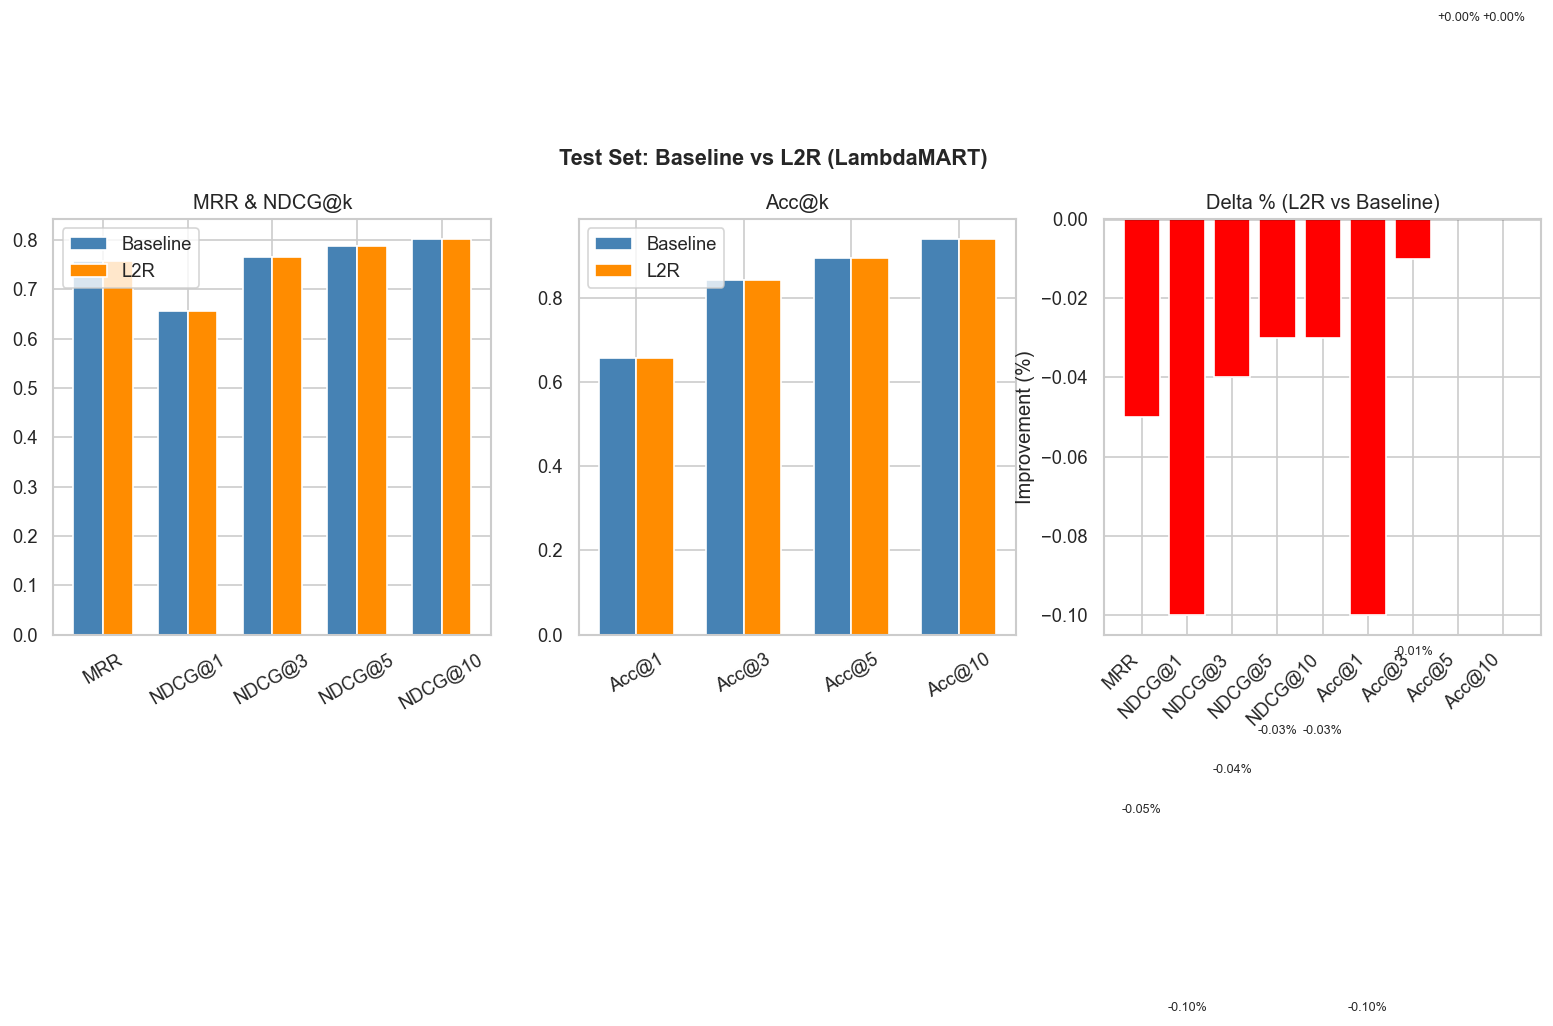

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
bar_width = 0.35

# MRR & NDCG
ndcg_keys = ['MRR'] + ['NDCG@%d' % k for k in KS]
x = np.arange(len(ndcg_keys))
axes[0].bar(x - bar_width/2, [baseline_test_metrics[m] for m in ndcg_keys], bar_width, label='Baseline', color='steelblue')
axes[0].bar(x + bar_width/2, [l2r_test_metrics[m]      for m in ndcg_keys], bar_width, label='L2R',      color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(ndcg_keys, rotation=30)
axes[0].set_title('MRR & NDCG@k'); axes[0].legend()

# Acc@k
acc_keys = ['Acc@%d' % k for k in KS]
x2 = np.arange(len(acc_keys))
axes[1].bar(x2 - bar_width/2, [baseline_test_metrics[m] for m in acc_keys], bar_width, label='Baseline', color='steelblue')
axes[1].bar(x2 + bar_width/2, [l2r_test_metrics[m]      for m in acc_keys], bar_width, label='L2R',      color='darkorange')
axes[1].set_xticks(x2); axes[1].set_xticklabels(acc_keys, rotation=30)
axes[1].set_title('Acc@k'); axes[1].legend()

# Delta %
delta_vals  = comparison['Delta %'].values
bar_colors  = ['green' if v >= 0 else 'red' for v in delta_vals]
x3 = np.arange(len(metrics_keys))
axes[2].bar(x3, delta_vals, color=bar_colors, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xticks(x3); axes[2].set_xticklabels(metrics_keys, rotation=45, ha='right')
axes[2].set_ylabel('Improvement (%)')
axes[2].set_title('Delta % (L2R vs Baseline)')
for i, v in enumerate(delta_vals):
    axes[2].text(i, v + (0.05 if v >= 0 else -0.10), '%+.2f%%' % v, ha='center', fontsize=7.5)

plt.suptitle('Test Set: Baseline vs L2R (LambdaMART)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Feature Importance

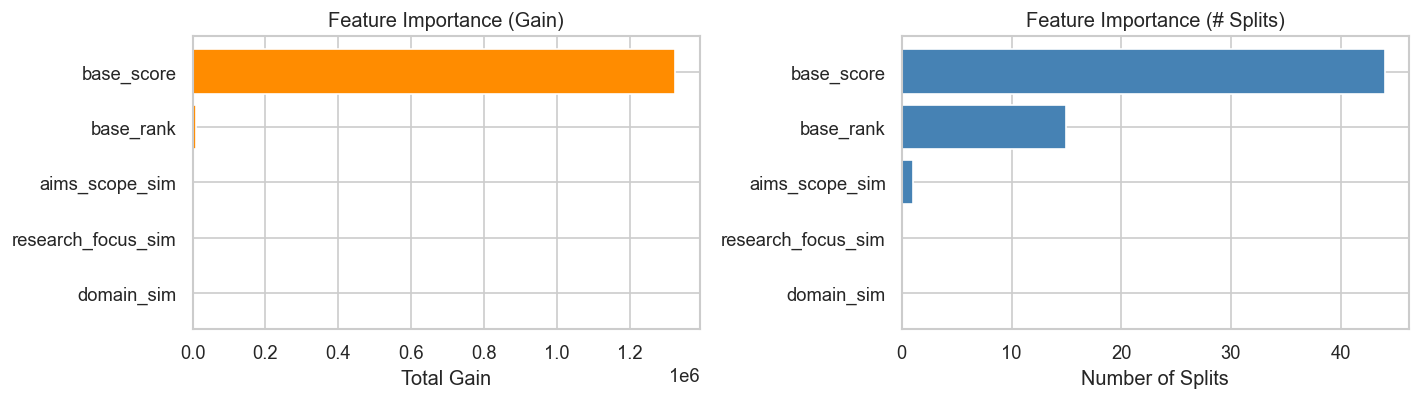


Feature Importance (Gain):
  base_score                ██████████████████████████████ 1325937.4
  base_rank                 █ 9888.7
  aims_scope_sim            █ 51.3
  domain_sim                █ 0.0
  research_focus_sim        █ 0.0


In [14]:
imp_gain  = model.feature_importance(importance_type='gain')
imp_split = model.feature_importance(importance_type='split')

fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Gain': imp_gain, 'Split': imp_split})\
          .sort_values('Gain', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].barh(fi_df['Feature'], fi_df['Gain'],  color='darkorange')
axes[0].set_title('Feature Importance (Gain)'); axes[0].set_xlabel('Total Gain')
axes[1].barh(fi_df['Feature'], fi_df['Split'], color='steelblue')
axes[1].set_title('Feature Importance (# Splits)'); axes[1].set_xlabel('Number of Splits')
plt.tight_layout()
plt.show()

print('\nFeature Importance (Gain):')
for _, row in fi_df.sort_values('Gain', ascending=False).iterrows():
    bar = chr(9608) * max(1, int(row['Gain'] / (fi_df['Gain'].max() or 1) * 30))
    print('  %-25s %s %.1f' % (row['Feature'], bar, row['Gain']))

## 9. Rank Shift Analysis

L2R kéo correct journal lên / xuống như thế nào so với base model.

In [15]:
correct_test = df_test_ranked[df_test_ranked['Is_Correct'] == 1]\
    [['Paper_ID', 'Base_Rank', 'L2R_Rank']].copy()
correct_test['Rank_Change'] = correct_test['Base_Rank'] - correct_test['L2R_Rank']  # positive = improved

improved  = (correct_test['Rank_Change'] > 0).sum()
unchanged = (correct_test['Rank_Change'] == 0).sum()
degraded  = (correct_test['Rank_Change'] < 0).sum()

print('Papers analyzed            :', f'{len(correct_test):,}')
print('Improved  (rank moved up)  :', f'{improved:,}',  '(%.1f%%)' % (improved  / len(correct_test) * 100))
print('Unchanged                  :', f'{unchanged:,}', '(%.1f%%)' % (unchanged / len(correct_test) * 100))
print('Degraded  (rank moved down):', f'{degraded:,}',  '(%.1f%%)' % (degraded  / len(correct_test) * 100))

Papers analyzed            : 33,913
Improved  (rank moved up)  : 245 (0.7%)
Unchanged                  : 33,438 (98.6%)
Degraded  (rank moved down): 230 (0.7%)


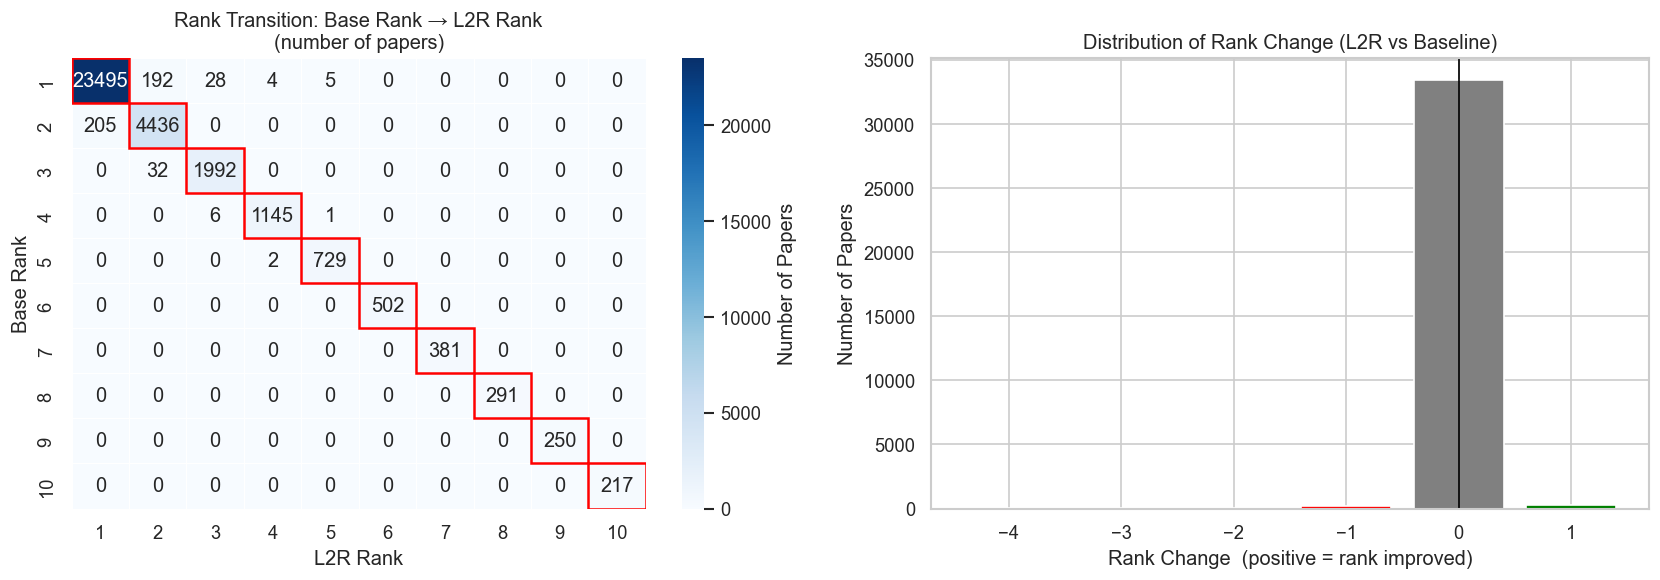

In [16]:
transition = pd.crosstab(
    correct_test['Base_Rank'],
    correct_test['L2R_Rank'],
    rownames=['Base Rank'],
    colnames=['L2R Rank'],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(transition, annot=True, fmt='d', cmap='Blues',
            linewidths=0.3, ax=axes[0], cbar_kws={'label': 'Number of Papers'})
axes[0].set_title('Rank Transition: Base Rank → L2R Rank\n(number of papers)')
for i in range(min(transition.shape)):
    axes[0].add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='red', lw=1.5))

rank_change_counts = correct_test['Rank_Change'].value_counts().sort_index()
bar_colors = ['green' if x > 0 else ('red' if x < 0 else 'gray') for x in rank_change_counts.index]
axes[1].bar(rank_change_counts.index, rank_change_counts.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Rank Change  (positive = rank improved)')
axes[1].set_ylabel('Number of Papers')
axes[1].set_title('Distribution of Rank Change (L2R vs Baseline)')

plt.tight_layout()
plt.show()

In [17]:
promoted    = correct_test[(correct_test['Base_Rank'] > 1) & (correct_test['L2R_Rank'] == 1)]
demoted     = correct_test[(correct_test['Base_Rank'] == 1) & (correct_test['L2R_Rank'] > 1)]

print('Promoted  to rank-1 (was rank 2+) :', f'{len(promoted):,}', 'papers')
print('Demoted from rank-1 (now rank 2+) :', f'{len(demoted):,}',  'papers')
print('Net gain at Acc@1                 : %+d papers' % (len(promoted) - len(demoted)))

if len(promoted) > 0:
    print('\nSample papers promoted to rank-1:')
    print(promoted.head(10).to_string(index=False))

Promoted  to rank-1 (was rank 2+) : 205 papers
Demoted from rank-1 (now rank 2+) : 229 papers
Net gain at Acc@1                 : -24 papers

Sample papers promoted to rank-1:
 Paper_ID  Base_Rank  L2R_Rank  Rank_Change
     2172          2         1            1
     2764          2         1            1
     3211          2         1            1
     4512          2         1            1
     8248          2         1            1
     9016          2         1            1
     9177          2         1            1
     9208          2         1            1
     9430          2         1            1
    12329          2         1            1


## 10. Final Summary — Val & Test

In [18]:
rows = []
for split, base_m, l2r_m in [
    ('Val',  baseline_val_metrics,  l2r_val_metrics),
    ('Test', baseline_test_metrics, l2r_test_metrics),
]:
    for m in metrics_keys:
        rows.append({
            'Split'   : split,
            'Metric'  : m,
            'Baseline': base_m[m],
            'L2R'     : l2r_m[m],
            'Delta'   : l2r_m[m] - base_m[m],
            'Delta %' : (l2r_m[m] - base_m[m]) / base_m[m] * 100,
        })

summary_df = pd.DataFrame(rows).set_index(['Split', 'Metric'])

display(
    summary_df.style
    .format({'Baseline': '{:.4f}', 'L2R': '{:.4f}', 'Delta': '{:+.4f}', 'Delta %': '{:+.2f}%'})
    .applymap(color_delta, subset=['Delta', 'Delta %'])
    .set_caption('Before vs After L2R — Val & Test')
)

## 11. Save Outputs

In [19]:
import joblib

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'l2r_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path  = os.path.join(OUTPUT_DIR, 'l2r_lightgbm_model.pkl')
joblib.dump(model, model_path)
print('Model saved   ->', model_path)

test_out = os.path.join(OUTPUT_DIR, 'test_l2r_predictions.csv')
df_test_ranked.to_csv(test_out, index=False)
print('Predictions   ->', test_out)

metrics_out = os.path.join(OUTPUT_DIR, 'metrics_comparison.csv')
summary_df.reset_index().to_csv(metrics_out, index=False)
print('Metrics table ->', metrics_out)

print('\nDone!')

Model saved   -> c:\Users\Admin\Downloads\MedPRS\l2r_output\l2r_lightgbm_model.pkl
Predictions   -> c:\Users\Admin\Downloads\MedPRS\l2r_output\test_l2r_predictions.csv
Metrics table -> c:\Users\Admin\Downloads\MedPRS\l2r_output\metrics_comparison.csv

Done!
